# DATA 620 — Assignment: 2-Mode Network Analysis (Davis Southern Women)

**Zoran Glisovic | DATA620 — Web Analytics | Summer 2026**

This notebook analyzes the Davis Southern Women dataset — a 2-mode (bipartite) network recording which of 18 women attended which of 14 social events in 1930s Natchez, Mississippi. Edges only ever connect a woman to an event, never woman-to-woman or event-to-event directly, which is what makes this a two-mode network rather than an ordinary social graph.

## Background

The assignment page links to two pages for the dataset's description and raw data, both hosted at `vlado.fmf.uni-lj.si`. Both links time out.

The same dataset is available directly inside NetworkX as a built-in graph, `nx.davis_southern_women_graph()`, sourced from the same original study (Davis, Gardner, and Gardner, 1941) the broken links were pointing to. NetworkX's own documentation gallery (the third reference link on the assignment page, which does work) uses this exact function and projection approach, extended here to also cover the events side.

## 1. Setup

In [9]:
import networkx as nx                  # graph construction and bipartite algorithms
from networkx.algorithms import bipartite  # two-mode projection
import matplotlib.pyplot as plt        # network visualization
import matplotlib.patches as mpatches  # legend swatches

## 2. Load the Two-Mode Network

`bipartite_graph.graph['top']` and `bipartite_graph.graph['bottom']` hold the two node sets -- women and events -- with edges only running between them.

In [10]:
bipartite_graph = nx.davis_southern_women_graph()  # load the built-in 2-mode dataset
women  = bipartite_graph.graph['top']     # the 18 women
events = bipartite_graph.graph['bottom']  # the 14 events

print(f'{len(women)} women, {len(events)} events, {bipartite_graph.number_of_edges()} attendance ties')  # sanity check


18 women, 14 events, 89 attendance ties


## 3. Projecting onto Women and onto Events

`bipartite.weighted_projected_graph` collapses one side of the bipartite graph, connecting two nodes whenever they share at least one neighbor on the other side, weighted by how many they share. Projecting onto the women gives a "shared event attendance" network; projecting onto the events gives a "shared attendee" network -- the same approach NetworkX's own example uses for the women, applied here to both sides since the assignment asks about each.

In [11]:
# project the bipartite graph onto each side -- edge weight = number of shared ties
women_network  = bipartite.weighted_projected_graph(bipartite_graph, women)
events_network = bipartite.weighted_projected_graph(bipartite_graph, events)

# weighted degree = total shared-attendance overlap with everyone else on the same side
print('Weighted degree in the women projection (total shared-event overlap):')
for name, total in sorted(women_network.degree(weight='weight'), key=lambda x: -x[1]):
    print(f'  {name:<20} {total}')

print()
print('Weighted degree in the event projection (total shared-attendee overlap):')
for name, total in sorted(events_network.degree(weight='weight'), key=lambda x: -x[1]):
    print(f'  {name:<6} {total}')


Weighted degree in the women projection (total shared-event overlap):
  Theresa Anderson     57
  Evelyn Jefferson     50
  Brenda Rogers        46
  Sylvia Avondale      46
  Laura Mandeville     45
  Nora Fayette         43
  Ruth DeSand          40
  Verne Sanderson      38
  Katherina Rogers     37
  Eleanor Nye          36
  Helen Lloyd          34
  Myra Liddel          33
  Frances Anderson     32
  Pearl Oglethorpe     31
  Charlotte McDowd     24
  Dorothy Murchison    24
  Olivia Carleton      14
  Flora Price          14

Weighted degree in the event projection (total shared-attendee overlap):
  E8     59
  E7     48
  E9     46
  E6     41
  E5     38
  E3     32
  E12    28
  E10    25
  E4     23
  E2     20
  E1     19
  E13    18
  E14    18
  E11    13


## 4. Visualizing the Bipartite Network

Women and events are placed in two fixed columns on purpose, rather than a spring layout -- this keeps the bipartite structure visible, unlike the mixed-node-type spring layout used in the NetworkX example linked in the assignment.

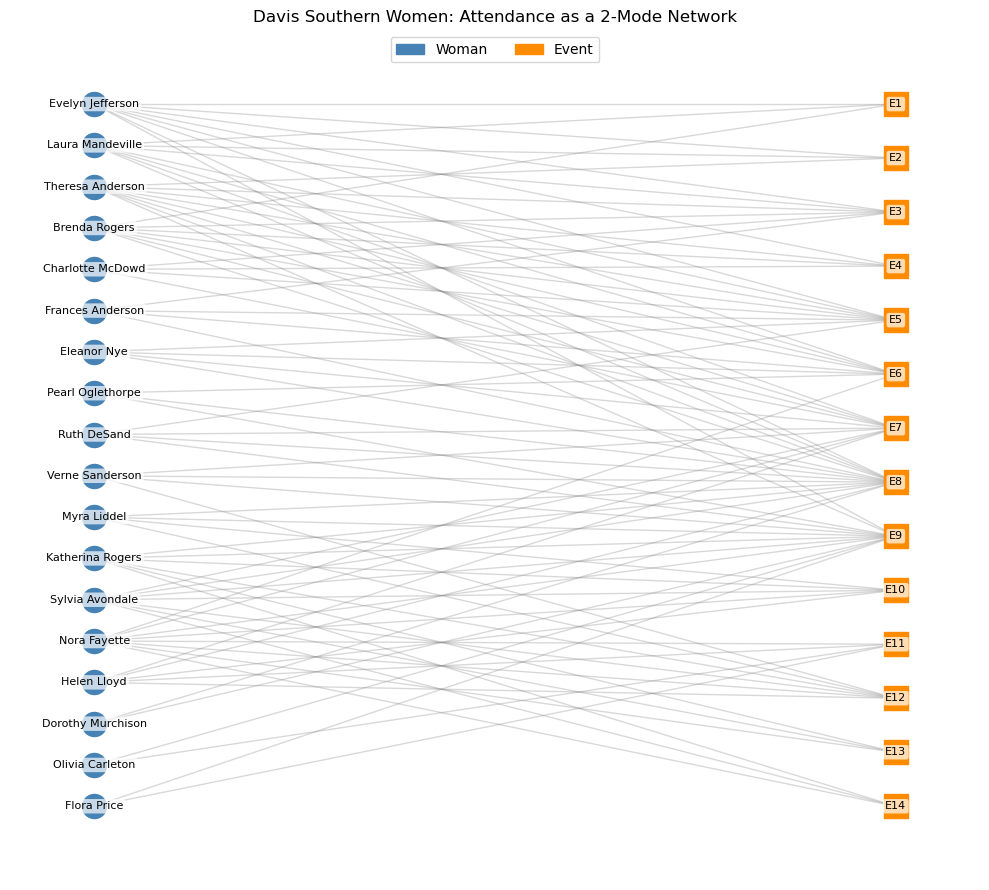

In [12]:
WOMEN_COLOR  = 'steelblue'
EVENTS_COLOR = 'darkorange'

pos = {}  # two-column layout: women on the left, events on the right
for i, name in enumerate(women):
    pos[name] = (0, -i)
for i, name in enumerate(events):
    pos[name] = (1, -i * (len(women) - 1) / (len(events) - 1))

fig, ax = plt.subplots(figsize=(10, 9))
nx.draw_networkx_edges(bipartite_graph, pos, ax=ax, alpha=0.3, edge_color='gray')  # edges behind nodes
nx.draw_networkx_nodes(bipartite_graph, pos, ax=ax, nodelist=women, node_color=WOMEN_COLOR)
nx.draw_networkx_nodes(bipartite_graph, pos, ax=ax, nodelist=events, node_color=EVENTS_COLOR, node_shape='s')
nx.draw_networkx_labels(bipartite_graph, pos, ax=ax, font_size=8,
                         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))  # readable label background
ax.legend(handles=[mpatches.Patch(color=WOMEN_COLOR, label='Woman'),
                    mpatches.Patch(color=EVENTS_COLOR, label='Event')], loc='upper center', ncol=2)
ax.set_title('Davis Southern Women: Attendance as a 2-Mode Network')
ax.axis('off')
plt.tight_layout()
plt.savefig('davis_southern_women_bipartite.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Summary and Interpretation

**About the women:** Theresa Anderson (57) and Evelyn Jefferson (50) have the highest total shared-event overlap with the rest of the group, meaning they are each tied to the broadest cross-section of other women through joint event attendance -- the closest thing this dataset has to socially central members. Olivia Carleton and Flora Price sit at the opposite end, tied at 14 -- well below everyone else -- suggesting much more peripheral participation in the group's social calendar.

**About the events:** Event E8 has the highest shared-attendee overlap with other events (59), clearly ahead of E7 (48) and E9 (46), meaning the same broad set of women who attended E8 also turned out for many of the other events -- it functions as the social anchor of the dataset. Event E11 has the lowest overlap (13), suggesting it drew a narrower, more self-contained subset of attendees.

**Limitation:** projecting the bipartite graph collapses two women attending 3 events together into a single edge weighted 3 -- useful for ranking connectivity, but it can't say which events drove that overlap without going back to the original bipartite graph above.